# SISTECH 2026 — MLOps Hands-On 1
## Risk Score Feature & Label Engineering (Chicago Crimes)

**Nama:** Lutfiana Putri Amalia

Notebook ini membangun **dataset fitur + label** untuk sistem prediksi **Risk Score
(0–100)** — skor yang menggambarkan tingkat risiko suatu lokasi pada waktu tertentu,
berdasarkan pola kejahatan historis (dataset **Chicago Crimes**).

Alur: **EDA -> Feature Engineering (temporal & spasial) -> Pseudo-Labeling (severity +
space-time decay) -> Dataset Akhir**.


# 0. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import BallTree

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
np.random.seed(42)
print("Setup selesai")

Setup selesai


# 1. Load Dataset

Dataset yang dipakai adalah file CSV **Chicago Crimes** yang sudah diberikan (ekspor
tanggal 13 Juli 2026). Kita cek dulu cakupannya sebelum memutuskan perlu subset lagi
atau tidak.

In [ ]:
usecols = ["ID", "Date", "Primary Type", "Description", "Location Description",
           "Arrest", "Domestic", "Latitude", "Longitude", "Year"]
df = pd.read_csv("chicago_crimes.csv", usecols=lambda c: c in usecols)
print("Shape mentah:", df.shape)
df["Year"].value_counts().sort_index()

Shape mentah: (231214, 10)


Year
2025    117379
2026    113835
Name: count, dtype: int64

### Keputusan Subset

Dataset yang diberikan **sudah dalam bentuk subset** (231.214 baris, hanya tahun
**2025–2026**, bukan basis penuh 2001–sekarang yang berjumlah jutaan baris). Karena
ukurannya sudah ringan untuk dikomputasi (~230 ribu baris), **kita pakai seluruh data
yang diberikan tanpa subsetting tambahan** — cakupannya persis 1 tahun terakhir,
yang relevan untuk menangkap pola risiko *terkini* (sesuai tujuan sistem: prediksi
risiko operasional, bukan riset historis jangka panjang).

# 2. Pembersihan Data (Cleaning)

Langkah: parse `Date` -> datetime, buang baris tanpa koordinat/tanggal valid, filter
koordinat di luar bounding box kasar Chicago, lalu ekstrak fitur waktu dasar
(`hour`, `dow`, `month`, `is_weekend`).

In [ ]:
df["Datetime"] = pd.to_datetime(df["Date"], format="%m/%d/%Y %I:%M:%S %p", errors="coerce")

before = len(df)
df = df.dropna(subset=["Latitude", "Longitude", "Datetime"]).copy()
df = df[df["Latitude"].between(41.60, 42.05) & df["Longitude"].between(-87.95, -87.50)].copy()
print(f"Shape setelah cleaning: {df.shape}  (dibuang: {before - len(df)} baris)")

df["hour"] = df["Datetime"].dt.hour
df["dow"] = df["Datetime"].dt.dayofweek          # 0 = Senin ... 6 = Minggu
df["month"] = df["Datetime"].dt.month
df["is_weekend"] = df["dow"].isin([5, 6])

print("Rentang tanggal:", df["Datetime"].min(), "->", df["Datetime"].max())
print("Cakupan:", (df["Datetime"].max() - df["Datetime"].min()).days, "hari")

Shape setelah cleaning: (231126, 11)  (dibuang: 88 baris)
Rentang tanggal: 2025-07-06 00:00:00 -> 2026-07-04 00:00:00
Cakupan: 363 hari


# 3. Exploratory Data Analysis (EDA)

Fokus: pola **waktu** (jam/hari/bulan) dan **lokasi** (hotspot spasial), plus
beberapa interaksi (weekday vs weekend, dow x hour) untuk membangun intuisi yang
memandu feature engineering & pseudo-labeling.

## 3.1 Jenis Kejahatan Paling Umum

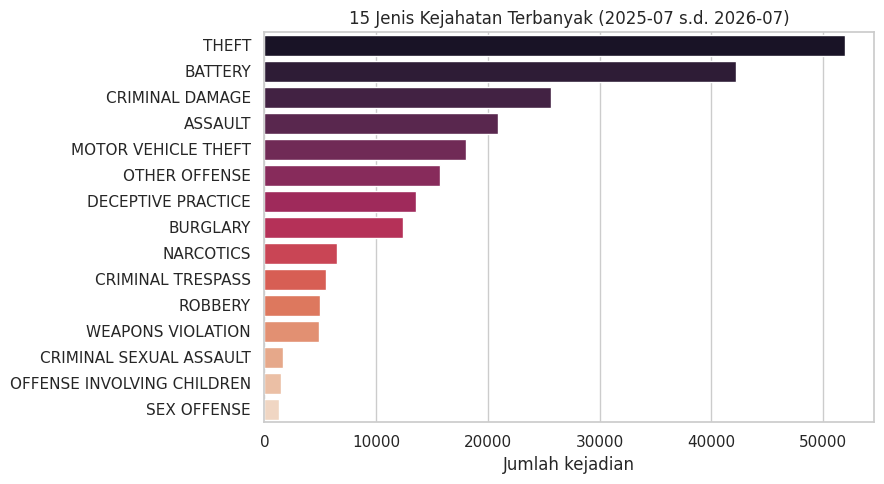

THEFT + BATTERY + CRIMINAL DAMAGE + ASSAULT saja sudah = 60.9% dari seluruh kejadian.


In [ ]:
top_types = df["Primary Type"].value_counts().head(15)

plt.figure(figsize=(9, 5))
sns.barplot(x=top_types.values, y=top_types.index, hue=top_types.index,
            palette="rocket", legend=False)
plt.title("15 Jenis Kejahatan Terbanyak (2025-07 s.d. 2026-07)")
plt.xlabel("Jumlah kejadian"); plt.ylabel("")
plt.tight_layout(); plt.show()

print(f"THEFT + BATTERY + CRIMINAL DAMAGE + ASSAULT saja sudah = "
      f"{top_types.iloc[:4].sum() / len(df) * 100:.1f}% dari seluruh kejadian.")

**Insight:** empat jenis kejahatan (`THEFT`, `BATTERY`, `CRIMINAL DAMAGE`,
`ASSAULT`) mendominasi data. Ini penting untuk severity table: kombinasi
Primary Type + Description dari keempat jenis ini **wajib** ditangani dengan baik
karena menentukan sebagian besar total Risk Score.

## 3.2 Pola Temporal — Jam, Hari, Weekday vs Weekend

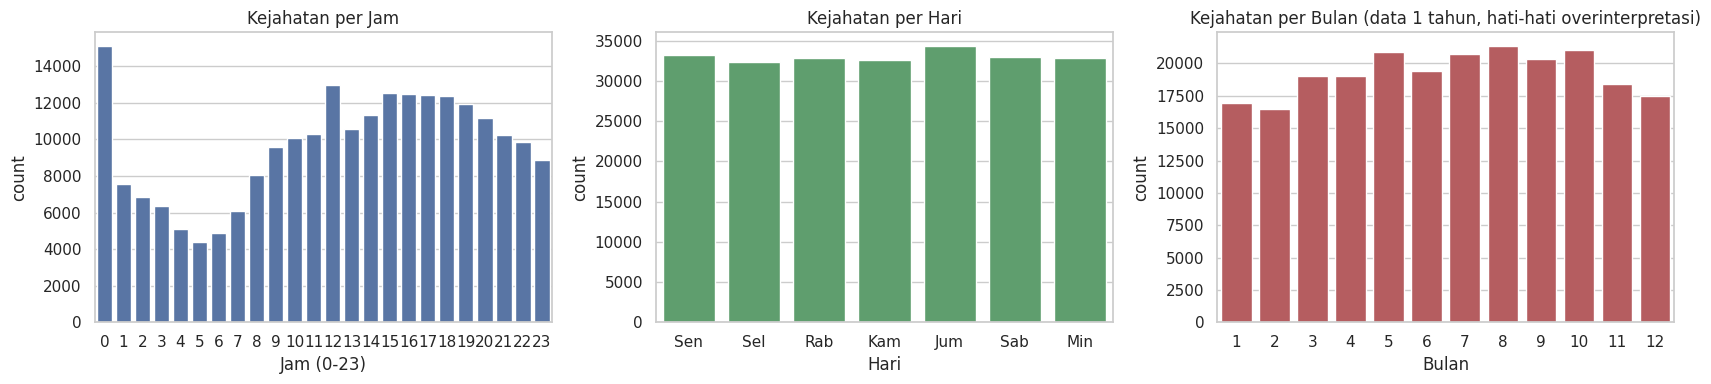

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

sns.countplot(x="hour", data=df, ax=axes[0], color="#4C72B0")
axes[0].set_title("Kejahatan per Jam"); axes[0].set_xlabel("Jam (0-23)")

labels_dow = ["Sen", "Sel", "Rab", "Kam", "Jum", "Sab", "Min"]
sns.countplot(x="dow", data=df, order=[0,1,2,3,4,5,6], ax=axes[1], color="#55A868")
axes[1].set_title("Kejahatan per Hari"); axes[1].set_xlabel("Hari")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(labels_dow)

sns.countplot(x="month", data=df, ax=axes[2], color="#C44E52")
axes[2].set_title("Kejahatan per Bulan (data 1 tahun, hati-hati overinterpretasi)")
axes[2].set_xlabel("Bulan")

plt.tight_layout(); plt.show()

**Insight & catatan kualitas data:** jam `00:00` punya jumlah kejadian yang jauh
lebih tinggi dari jam sekitarnya — ini **bukan** pola kriminal asli, melainkan
artefak pencatatan (kejadian dengan waktu tidak pasti sering dibulatkan/didefaultkan
ke tengah malam). Ini perlu diwaspadai saat interpretasi fitur `hour`. Di luar jam
00:00, kejahatan cenderung meningkat dari sore hingga malam (16:00–21:00) dan
menurun di dini hari (03:00–06:00). Karena data hanya mencakup ~1 tahun (bukan
banyak tahun), pola **bulanan** di atas mencerminkan **satu siklus musiman saja**
dan sebaiknya dianggap indikatif, bukan konklusif.

## 3.3 Weekday vs Weekend — Pola Jam Berbeda?

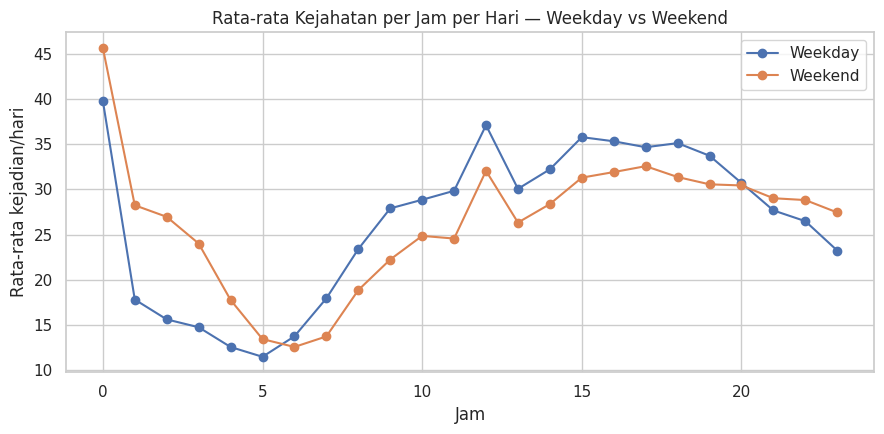

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for is_wknd, label, color in [(False, "Weekday", "#4C72B0"), (True, "Weekend", "#DD8452")]:
    sub = df[df["is_weekend"] == is_wknd]
    n_days = sub["Datetime"].dt.date.nunique()
    rate = sub["hour"].value_counts().sort_index() / n_days
    ax.plot(rate.index, rate.values, marker="o", label=label, color=color)
ax.set_title("Rata-rata Kejahatan per Jam per Hari — Weekday vs Weekend")
ax.set_xlabel("Jam"); ax.set_ylabel("Rata-rata kejadian/hari")
ax.legend(); plt.tight_layout(); plt.show()

**Insight:** pola jam weekend condong bergeser — dini hari (00:00–04:00)
proporsinya lebih tinggi di weekend (konsisten dengan aktivitas malam/hiburan di
akhir pekan), sementara puncak siang hari weekday sedikit lebih tajam (konsisten
pola aktivitas kerja/komuter). Ini menjadi salah satu alasan kita tetap
mempertahankan `dow` (bukan hanya `is_weekend`) sebagai bagian dari unit analisis —
info hari spesifik hilang jika hanya weekday/weekend biner.

## 3.4 Interaksi Hari x Jam (Heatmap)

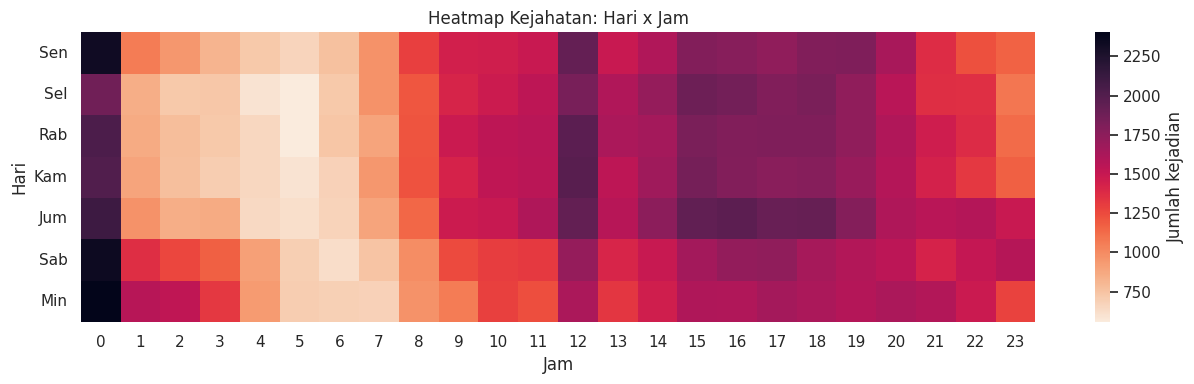

In [ ]:
pivot = df.pivot_table(index="dow", columns="hour", values="ID", aggfunc="count")
plt.figure(figsize=(13, 4))
sns.heatmap(pivot, cmap="rocket_r", cbar_kws={"label": "Jumlah kejadian"})
plt.yticks(np.arange(7) + 0.5, labels_dow, rotation=0)
plt.title("Heatmap Kejahatan: Hari x Jam")
plt.xlabel("Jam"); plt.ylabel("Hari")
plt.tight_layout(); plt.show()

**Insight:** intensitas kejahatan bukan sekadar penjumlahan efek "hari" dan
"jam" secara independen — ada interaksi (mis. dini hari akhir pekan jelas lebih
ramai dibanding dini hari hari kerja). Ini menjustifikasi keputusan desain kita
memakai **unit analisis gabungan (sel grid x hari x jam)**, bukan memisah fitur
hari dan jam sebagai agregat terpisah.

## 3.5 Pola Spasial — Hotspot

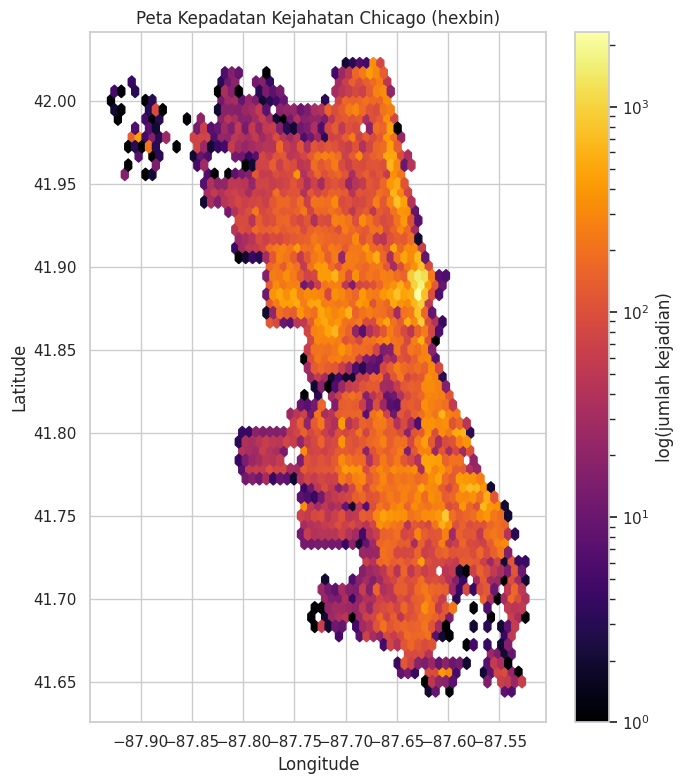

In [ ]:
plt.figure(figsize=(7, 8))
hb = plt.hexbin(df["Longitude"], df["Latitude"], gridsize=60,
                cmap="inferno", mincnt=1, bins="log")
plt.colorbar(hb, label="log(jumlah kejadian)")
plt.title("Peta Kepadatan Kejahatan Chicago (hexbin)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()

**Insight:** kejahatan **tidak** tersebar merata — ada beberapa klaster
kepadatan tinggi (konsisten dengan area padat penduduk/komersial di Chicago) yang
dikelilingi area jarang. Ini jadi alasan utama kita butuh **spatial decay/smoothing**
saat membentuk Risk Score: sebuah titik yang persis di pinggir hotspot semestinya
tetap dianggap berisiko lebih tinggi daripada titik yang jauh dari hotspot manapun,
meskipun secara harfiah "sel"-nya sendiri sepi kejadian.

## 3.6 Tingkat Penangkapan (Arrest Rate) per Jenis Kejahatan

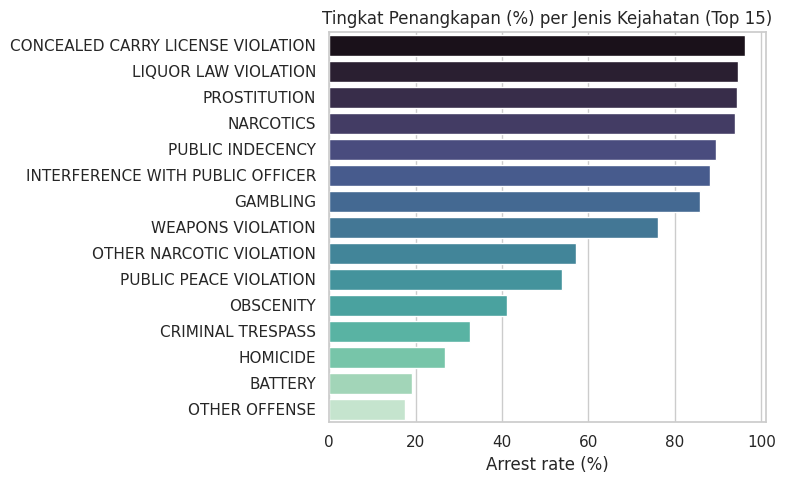

Arrest rate keseluruhan: 15.2%


In [ ]:
arrest_by_type = (df.groupby("Primary Type")["Arrest"].mean()
                    .sort_values(ascending=False).head(15))
plt.figure(figsize=(8, 5))
sns.barplot(x=arrest_by_type.values * 100, y=arrest_by_type.index,
            hue=arrest_by_type.index, palette="mako", legend=False)
plt.title("Tingkat Penangkapan (%) per Jenis Kejahatan (Top 15)")
plt.xlabel("Arrest rate (%)"); plt.ylabel("")
plt.tight_layout(); plt.show()
print(f"Arrest rate keseluruhan: {df['Arrest'].mean()*100:.1f}%")

**Insight:** arrest rate keseluruhan hanya sekitar 15%, dan bervariasi tajam
antar jenis kejahatan. Fitur ini **tidak** kita jadikan komponen Risk Score (arrest
adalah hasil respons penegak hukum, bukan indikator risiko lokasi itu sendiri — dan
memakainya berisiko menciptakan *feedback loop*/bias jika model dipakai untuk
menentukan penempatan patroli). Kita simpan `arrest_rate` di dataset akhir sebagai
fitur tambahan opsional untuk Hands-On 2, bukan bagian dari label.

# 4. Feature Engineering

Dua kelompok fitur: **Temporal** (cyclical encoding) dan **Spasial** (grid
aggregation).

## 4.1 Fitur Temporal — Cyclical Encoding

Waktu bersifat siklikal: jam `23:00` sebenarnya berdekatan dengan `00:00`, dan
Desember berdekatan dengan Januari — representasi linear (angka mentah) akan
membuat model menganggap ujung-ujung siklus ini **berjauhan**. Solusinya: petakan
tiap nilai siklikal ke lingkaran satuan dengan `sin` & `cos`.

In [ ]:
def cyclical_encode(values, period):
    radians = 2 * np.pi * values / period
    return np.sin(radians), np.cos(radians)

df["hour_sin"], df["hour_cos"] = cyclical_encode(df["hour"], 24)
df["dow_sin"], df["dow_cos"] = cyclical_encode(df["dow"], 7)
df["month_sin"], df["month_cos"] = cyclical_encode(df["month"], 12)

# Bukti: jarak 23:00 -> 00:00 harus lebih kecil dari 00:00 -> 12:00
def point(v, p):
    return np.array(cyclical_encode(np.array([v]), p)).ravel()

d_23_0 = np.linalg.norm(point(23, 24) - point(0, 24))
d_0_12 = np.linalg.norm(point(0, 24) - point(12, 24))
print(f"Jarak 23:00 -> 00:00 = {d_23_0:.3f}  (kecil, sesuai harapan)")
print(f"Jarak 00:00 -> 12:00 = {d_0_12:.3f}  (besar, sesuai harapan)")

df[["hour", "hour_sin", "hour_cos", "dow", "dow_sin", "dow_cos"]].head()

Jarak 23:00 -> 00:00 = 0.261  (kecil, sesuai harapan)
Jarak 00:00 -> 12:00 = 2.000  (besar, sesuai harapan)


,hour,hour_sin,hour_cos,dow,dow_sin,dow_cos
0,0,0.0,1.0,5,-0.974928,-0.222521
1,0,0.0,1.0,5,-0.974928,-0.222521
2,0,0.0,1.0,5,-0.974928,-0.222521
3,0,0.0,1.0,5,-0.974928,-0.222521
4,0,0.0,1.0,5,-0.974928,-0.222521


**Catatan:** `month_sin`/`month_cos` kita hitung di level baris untuk
kelengkapan, tetapi **tidak dibawa ke unit analisis akhir** karena unit analisis
kita adalah (sel x hari x jam) — bulan sudah "melebur" di dalam agregasi tersebut.
Menyertakan bulan berarti unit analisis harus diperluas jadi (sel x bulan x hari x
jam), yang akan membuat data jauh lebih jarang (sparse) untuk cakupan 1 tahun ini.

## 4.2 Fitur Spasial — Grid Aggregation

Koordinat lintang/bujur kontinu perlu diubah menjadi **sel grid** diskrit agar
kejadian di area yang berdekatan bisa diagregasi dan dibandingkan.

**Pemilihan resolusi grid** — dicek secara empiris terhadap kepadatan data:

In [ ]:
for step in [0.01, 0.005, 0.003]:
    lat_r = (df["Latitude"] / step).round() * step
    lon_r = (df["Longitude"] / step).round() * step
    n_cells = (lat_r.round(4).astype(str) + "_" + lon_r.round(4).astype(str)).nunique()
    print(f"step={step:<6} (~{step*111:.0f}m) -> {n_cells:>6} sel, "
          f"rata-rata {len(df)/n_cells:6.1f} kejadian/sel")

step=0.01   (~1m) ->    711 sel, rata-rata  325.1 kejadian/sel


step=0.005  (~1m) ->   2450 sel, rata-rata   94.3 kejadian/sel


step=0.003  (~0m) ->   6134 sel, rata-rata   37.7 kejadian/sel


**Keputusan:** step **0.01** (~1.1 km) terlalu kasar untuk dataset 1-kota ini
(hanya 711 sel — resolusi terlalu rendah untuk membedakan lingkungan yang
berdekatan). Step **0.003** (~110 m) memberi rata-rata **<8 kejadian/sel**, yang
akan menjadi sangat jarang begitu dipecah lagi per (hari x jam) — 168 kombinasi
waktu per sel. Kita pilih **step = 0.005 (~550 m)**, titik tengah yang memberi
skala "lingkungan/beberapa blok" namun tetap punya kepadatan data yang cukup untuk
agregasi yang stabil secara statistik.

In [ ]:
STEP = 0.005
df["lat_r"] = ((df["Latitude"] / STEP).round() * STEP).round(4)
df["lon_r"] = ((df["Longitude"] / STEP).round() * STEP).round(4)
df["cell_id"] = df["lat_r"].astype(str) + "_" + df["lon_r"].astype(str)

print(f"Jumlah sel unik: {df['cell_id'].nunique():,}")
df[["Latitude", "Longitude", "lat_r", "lon_r", "cell_id"]].head()

Jumlah sel unik: 2,450


,Latitude,Longitude,lat_r,lon_r,cell_id
0,41.776150,-87.615523,41.775,-87.615,41.775_-87.615
1,41.874343,-87.674532,41.875,-87.675,41.875_-87.675
2,41.768921,-87.572703,41.770,-87.575,41.77_-87.575
3,41.972267,-87.690910,41.970,-87.690,41.97_-87.69
4,41.692570,-87.624398,41.695,-87.625,41.695_-87.625


# 5. Pseudo-Labeling -> Membentuk Risk Score

Unit analisis: **(sel grid x hari x jam)** — langsung menjawab definisi "risiko
suatu lokasi pada waktu tertentu". Alur: **severity -> temporal decay -> agregasi
per unit -> spatial smoothing -> normalisasi 0-100**.

## 5.1 Severity Scoring — Rule-Based (bukan lookup table statis)

Dataset ini punya **332 kombinasi unik** Primary Type x Description. Sebuah lookup
table manual untuk tiap kombinasi pasti punya *long tail* yang jatuh ke satu nilai
default generik (bahkan menutup 90% data pun masih butuh >50 baris tabel, dan 10%
sisanya tetap default seragam).

**Keputusan desain:** kita bangun severity sebagai **fungsi aturan (rule-based)**:
1. **Base score per Primary Type** — mengikuti hierarki keparahan yang dipakai FBI
   Uniform Crime Report (kejahatan kekerasan terhadap orang > kejahatan properti >
   pelanggaran ketertiban umum), diselaraskan secara kasar dengan klasifikasi
   felony/misdemeanor KUHP Illinois (mis. pembunuhan = Class M/felony tertinggi,
   pelanggaran ketertiban umum ringan = misdemeanor Class C).
2. **Modifier aditif berbasis kata kunci** di `Description`: keberadaan senjata
   (`HANDGUN`, `KNIFE`), status "aggravated" vs "simple", status korban rentan
   (anak, lansia), status domestik, cedera serius vs minor, dan status
   percobaan (`ATTEMPT`) vs selesai.

Pendekatan ini men-generalisasi ke **semua** kombinasi (termasuk yang belum pernah
muncul di data training), bukan hanya yang di-hardcode — dan setiap skor tetap bisa
dijustifikasi lewat kombinasi aturan yang dipakai, bukan angka yang diambil
sembarangan.

Kombinasi unik yang mendapat skor: 332

Distribusi severity:
count    231126.0
mean         33.6
std          18.2
min           2.0
25%          20.0
50%          27.0
75%          42.0
max         100.0
Name: severity, dtype: float64


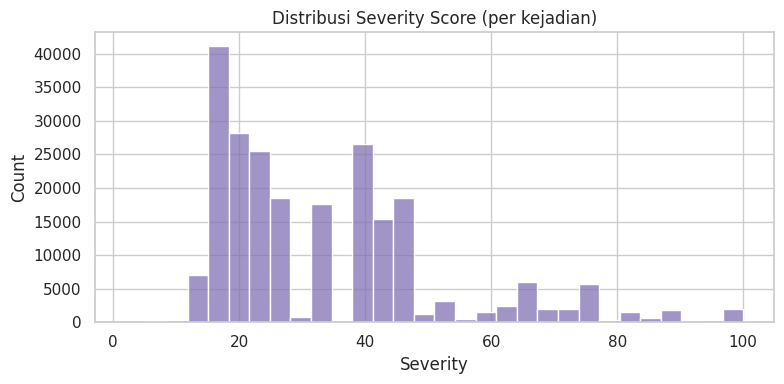

In [ ]:
PRIMARY_BASE = {
    "HOMICIDE": 100,
    "CRIMINAL SEXUAL ASSAULT": 90, "CRIM SEXUAL ASSAULT": 90,
    "HUMAN TRAFFICKING": 90,
    "KIDNAPPING": 85,
    "ARSON": 65,
    "ROBBERY": 55,
    "OFFENSE INVOLVING CHILDREN": 60,
    "SEX OFFENSE": 58,
    "ASSAULT": 42,
    "WEAPONS VIOLATION": 45,
    "BATTERY": 38,
    "STALKING": 40,
    "INTIMIDATION": 38,
    "BURGLARY": 38,
    "MOTOR VEHICLE THEFT": 33,
    "THEFT": 22,
    "CRIMINAL TRESPASS": 12,
    "CRIMINAL DAMAGE": 18,
    "DECEPTIVE PRACTICE": 20,
    "NARCOTICS": 25,
    "OTHER NARCOTIC VIOLATION": 22,
    "PROSTITUTION": 15,
    "INTERFERENCE WITH PUBLIC OFFICER": 22,
    "PUBLIC PEACE VIOLATION": 15,
    "OBSCENITY": 18, "PUBLIC INDECENCY": 18,
    "LIQUOR LAW VIOLATION": 6,
    "GAMBLING": 6,
    "CONCEALED CARRY LICENSE VIOLATION": 18,
    "NON-CRIMINAL": 2, "NON - CRIMINAL": 2,
    "OTHER OFFENSE": 20,
}
DEFAULT_BASE_UNKNOWN_TYPE = 20  # hanya kepakai jika Primary Type benar2 tak dikenal

MODIFIERS = [
    ("AGGRAVATED", 15), ("AGG.", 15), ("AGG ", 12),
    ("HANDGUN", 20), ("FIREARM", 20), ("GUN OFFENDER", 10),
    ("KNIFE", 12), ("CUTTING", 12),
    ("OTHER DANGEROUS WEAPON", 10),
    ("ARMED", 15),
    ("STRONG ARM", -8), ("NO WEAPON", -6),
    ("DOMESTIC", 8),
    ("SERIOUS INJURY", 15),
    ("NO / MINOR INJURY", -6), ("MINOR INJURY", -4),
    ("ATTEMPT", -10),
    ("CHILD", 10), ("SENIOR CITIZEN", 10), ("DISABLED", 10),
    ("POCKET-PICKING", 10), ("FROM PERSON", 10),
    ("$500 AND UNDER", -5), ("OVER $500", 5),
    ("FORCIBLE ENTRY", 8), ("FORCIBLE", 8),
    ("MANUFACTURE / DELIVER", 15), ("DELIVER", 10),
    ("FOUND SUSPECT", -8),
]

def score_combo(ptype, desc):
    base = PRIMARY_BASE.get(ptype, DEFAULT_BASE_UNKNOWN_TYPE)
    delta = sum(val for kw, val in MODIFIERS if kw in str(desc))
    return float(np.clip(base + delta, 0, 100))

# Precompute per kombinasi unik (jauh lebih cepat daripada apply per baris)
combo_unique = df[["Primary Type", "Description"]].drop_duplicates()
combo_unique["severity"] = combo_unique.apply(
    lambda r: score_combo(r["Primary Type"], r["Description"]), axis=1)
severity_map = combo_unique.set_index(["Primary Type", "Description"])["severity"]
df = df.join(severity_map, on=["Primary Type", "Description"])

print(f"Kombinasi unik yang mendapat skor: {len(combo_unique)}")
print("\nDistribusi severity:")
print(df["severity"].describe().round(1))

plt.figure(figsize=(8, 4))
sns.histplot(df["severity"], bins=30, color="#8172B3")
plt.title("Distribusi Severity Score (per kejadian)")
plt.xlabel("Severity"); plt.tight_layout(); plt.show()

In [ ]:
# Validasi: contoh kombinasi teratas + skornya (cek masuk akal / konsisten arah)
check = (df.groupby(["Primary Type", "Description"])
           .agg(n=("ID", "size"), severity=("severity", "first"))
           .sort_values("n", ascending=False).head(20))
check

n  severity
Primary Type        Description                                         
BATTERY             DOMESTIC BATTERY SIMPLE              18485      46.0
                    SIMPLE                               15098      38.0
CRIMINAL DAMAGE     TO VEHICLE                           14686      18.0
THEFT               $500 AND UNDER                       14575      17.0
MOTOR VEHICLE THEFT AUTOMOBILE                           14114      33.0
ASSAULT             SIMPLE                               14074      42.0
THEFT               OVER $500                            13286      27.0
                    RETAIL THEFT                         12525      22.0
CRIMINAL DAMAGE     TO PROPERTY                          10060      18.0
BURGLARY            BURGLARY FROM MOTOR VEHICLE           6591      38.0
THEFT               THEFT FROM MOTOR VEHICLE              5914      22.0
                    FROM BUILDING                         4023      22.0
WEAPONS VIOLATION   UNLAWFUL POSSESSION - HANDGUN         3682      65.0
ASSAULT             AGGRAVATED - HANDGUN                  3541      77.0
CRIMINAL TRESPASS   TO LAND                               3491      12.0
BURGLARY            FORCIBLE ENTRY                        3135      54.0
OTHER OFFENSE       TELEPHONE THREAT                      2906      20.0
DECEPTIVE PRACTICE  FINANCIAL IDENTITY THEFT OVER $ 300   2742      20.0
                    FRAUD OR CONFIDENCE GAME              2694      20.0
OTHER OFFENSE       HARASSMENT BY TELEPHONE               2501      20.0

**Validasi kualitatif:** urutan skor konsisten dengan intuisi — `ASSAULT /
AGGRAVATED - HANDGUN` (77) jauh lebih tinggi dari `ASSAULT / SIMPLE` (42);
`BURGLARY / FORCIBLE ENTRY` (54) lebih tinggi dari pelanggaran properti ringan
seperti `CRIMINAL TRESPASS / TO LAND` (12); `BATTERY / DOMESTIC BATTERY SIMPLE`
(46) sedikit lebih tinggi dari `BATTERY / SIMPLE` (38) karena elemen domestik. Ini
menunjukkan skema aturan menangkap gradasi keparahan yang bermakna, bukan sekadar
angka acak.

## 5.2 Temporal Decay — Exponential Half-Life (bukan linear)

**Pertanyaan:** apakah kejahatan 3 tahun lalu sama relevannya dengan kejahatan
kemarin? Tentu tidak. **Keputusan desain:** pakai peluruhan **eksponensial**,
bukan **linear** seperti versi paling sederhana. Alasannya:
- Linear membuat kejadian **tertua** bernilai *persis* 0 (kehilangan informasi
  total) dan mengasumsikan laju penurunan relevansi konstan sepanjang waktu.
- Eksponensial merepresentasikan penurunan **proporsional** (persentase tetap)
  per satuan waktu — sesuai intuisi umum tentang "berita basi": kejadian minggu
  lalu terasa jauh lebih signifikan drop-nya dibanding kejadian setahun lalu vs
  dua tahun lalu (yang keduanya sama-sama "basi").

Kita pakai **half-life = 90 hari**: kejahatan berumur 90 hari berkontribusi
setengah dari kejahatan hari ini; 180 hari -> seperempat, dst. **Justifikasi
parameter:** untuk kebutuhan operasional (mis. alokasi patroli), tren kuartal
terakhir jauh lebih relevan daripada kejadian setahun lalu, tapi kita tidak ingin
sereaktif window mingguan (yang akan membuat skor terlalu volatil hari-ke-hari).

Reference date : 2026-07-04 00:00:00
w_time (bobot recency) describe:
count    231126.000
mean          0.334
std           0.261
min           0.061
25%           0.116
50%           0.236
75%           0.506
max           1.000
Name: w_time, dtype: float64


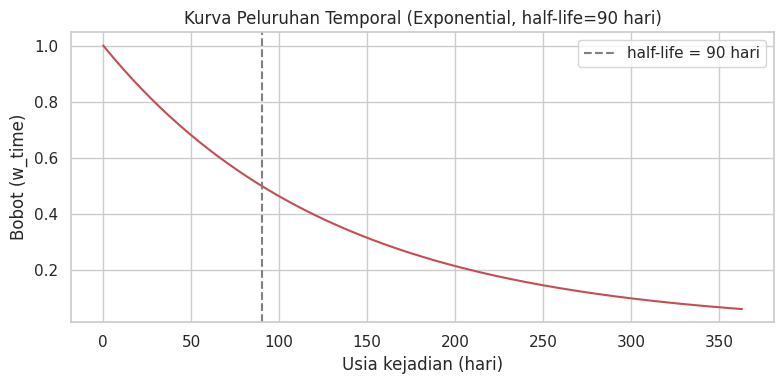

In [ ]:
REFERENCE_DATE = df["Datetime"].max()
HALF_LIFE_DAYS = 90.0

df["age_days"] = (REFERENCE_DATE - df["Datetime"]).dt.total_seconds() / 86400
df["w_time"] = 0.5 ** (df["age_days"] / HALF_LIFE_DAYS)
df["event_value"] = df["severity"] * df["w_time"]

print(f"Reference date : {REFERENCE_DATE}")
print("w_time (bobot recency) describe:")
print(df["w_time"].describe().round(3))

plt.figure(figsize=(8, 4))
age_range = np.linspace(0, df["age_days"].max(), 200)
plt.plot(age_range, 0.5 ** (age_range / HALF_LIFE_DAYS), color="#C44E52")
plt.axvline(90, ls="--", color="gray", label="half-life = 90 hari")
plt.title("Kurva Peluruhan Temporal (Exponential, half-life=90 hari)")
plt.xlabel("Usia kejadian (hari)"); plt.ylabel("Bobot (w_time)")
plt.legend(); plt.tight_layout(); plt.show()

### Membentuk Unit Analisis (sel x hari x jam)

Jumlahkan `event_value` (severity x recency) per unit untuk membentuk `base_value`.
Kita bawa juga `crime_count` (frekuensi murni — beda sifat dari `base_value` yang
menimbang keparahan x kebaruan: sebuah sel bisa punya banyak kejadian ringan
[count tinggi, base_value sedang] atau sedikit kejadian berat [count rendah,
base_value tinggi]) dan `arrest_rate` (disimpan sebagai fitur tambahan, bukan
bagian label — lihat justifikasi di bagian EDA 3.6).

In [ ]:
unit = (df.groupby(["cell_id", "lat_r", "lon_r", "dow", "hour"], as_index=False)
          .agg(base_value=("event_value", "sum"),
               crime_count=("ID", "size"),
               arrest_rate=("Arrest", "mean")))
print("Jumlah baris unit (sel x hari x jam):", f"{len(unit):,}")
unit.head()

Jumlah baris unit (sel x hari x jam): 138,663


,cell_id,lat_r,lon_r,dow,hour,base_value,crime_count,arrest_rate
0,41.645_-87.54,41.645,-87.54,0,5,5.125019,1,0.0
1,41.645_-87.54,41.645,-87.54,0,8,21.831348,1,0.0
2,41.645_-87.54,41.645,-87.54,0,16,14.455422,1,0.0
3,41.645_-87.54,41.645,-87.54,1,9,10.753544,1,0.0
4,41.645_-87.54,41.645,-87.54,1,15,2.960331,1,0.0


## 5.3 Spatial Decay — Gaussian Kernel via Haversine Distance (BallTree)

**Pertanyaan:** apakah risiko suatu sel hanya ditentukan kejadian tepat di sel itu,
atau area sekitarnya juga relevan? Tentu area sekitar juga relevan (lihat hotspot
di EDA 3.5) — tapi versi paling sederhana (rata-rata seragam 8 tetangga grid 3x3)
punya kelemahan: mengasumsikan **semua** tetangga sama pentingnya tanpa memandang
jarak sesungguhnya, dan grid lat/lon **tidak isotropic** (1 derajat longitude di
Chicago ~ 83 km, sementara 1 derajat latitude ~ 111 km — jarak "kotak" grid tidak
merepresentasikan jarak riil dengan tepat).

**Keputusan desain:** hitung jarak **great-circle (haversine)** riil antar sel
menggunakan `BallTree` scikit-learn, lalu beri bobot **kernel Gaussian** yang
menurun mulus terhadap jarak (bandwidth = 0.6 km), bukan potongan tegas
tetangga/bukan-tetangga. Smoothing dilakukan **per (hari, jam)** agar pola waktu
antar sel tidak tercampur.

In [ ]:
BW_KM = 0.6
EARTH_R_KM = 6371.0088
RADIUS_KM = 3 * BW_KM  # cutoff pencarian: 3x bandwidth, pengaruh di luar ini diabaikan

cell_coords = unit[["cell_id", "lat_r", "lon_r"]].drop_duplicates().reset_index(drop=True)
coords_rad = np.radians(cell_coords[["lat_r", "lon_r"]].values)
tree = BallTree(coords_rad, metric="haversine")
neighbor_idx, neighbor_dist = tree.query_radius(
    coords_rad, r=RADIUS_KM / EARTH_R_KM, return_distance=True)

cellid_to_pos = {cid: i for i, cid in enumerate(cell_coords["cell_id"])}

smoothed_chunks = []
for (dow_v, hour_v), grp in unit.groupby(["dow", "hour"]):
    val_by_pos = np.zeros(len(cell_coords))
    idx_map = grp["cell_id"].map(cellid_to_pos).values
    val_by_pos[idx_map] = grp["base_value"].values

    out = np.zeros(len(grp))
    for k, pos in enumerate(idx_map):
        nbrs = neighbor_idx[pos]
        dists_km = neighbor_dist[pos] * EARTH_R_KM
        weights = np.exp(-0.5 * (dists_km / BW_KM) ** 2)
        out[k] = np.average(val_by_pos[nbrs], weights=weights) if weights.sum() > 0 else val_by_pos[pos]

    tmp = grp.copy()
    tmp["risk_raw"] = out
    smoothed_chunks.append(tmp)

unit = pd.concat(smoothed_chunks, ignore_index=True)
print("risk_raw describe:")
print(unit["risk_raw"].describe().round(3))

risk_raw describe:
count    138663.000
mean         10.406
std           7.280
min           0.113
25%           5.286
50%           8.920
75%          13.799
max         116.450
Name: risk_raw, dtype: float64


## 5.4 Normalisasi -> Risk Score 0-100

`risk_raw` biasanya sangat *skewed* (sebagian besar sel/jam sepi, sedikit hotspot
sangat ramai). Mari cek dulu.

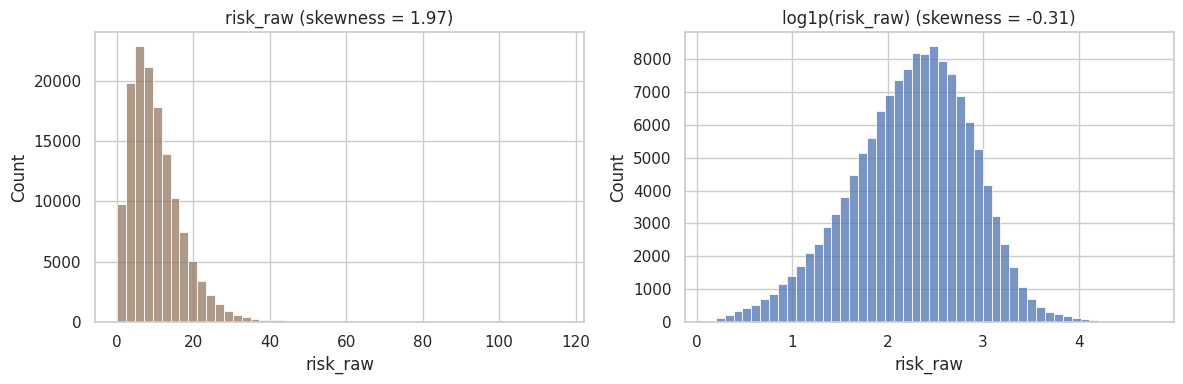

In [ ]:
from scipy.stats import skew

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(unit["risk_raw"], bins=50, ax=axes[0], color="#937860")
axes[0].set_title(f"risk_raw (skewness = {skew(unit['risk_raw']):.2f})")

sns.histplot(np.log1p(unit["risk_raw"]), bins=50, ax=axes[1], color="#4C72B0")
axes[1].set_title(f"log1p(risk_raw) (skewness = {skew(np.log1p(unit['risk_raw'])):.2f})")
plt.tight_layout(); plt.show()

**Keputusan:** min-max langsung ke `risk_raw` akan didominasi outlier
(sel/jam terpadat) dan menekan mayoritas sel ke ujung bawah skala. Kita pakai:
1. **`log1p`** untuk mengompres ekor distribusi (skewness turun drastis, terlihat
   di plot atas),
2. **clipping di persentil 99** sebelum scaling — agar segelintir sel paling
   ekstrem tidak mendominasi rentang skala,
3. **min-max ke 0-100** di atas hasil (1) & (2).

Pendekatan gabungan ini menjaga urutan relatif antar sel (lebih tinggi = lebih
berisiko) namun menghasilkan distribusi skor yang jauh lebih bisa dibedakan di
seluruh rentang, dibanding min-max mentah.

risk_score describe:
count    138663.00
mean         61.58
std          18.17
min           0.00
25%          49.93
50%          63.09
75%          74.62
max         100.00
Name: risk_score, dtype: float64
Skewness risk_score: -0.376


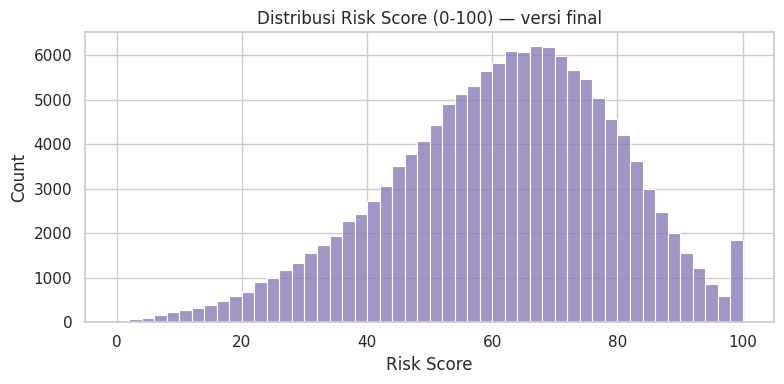

In [ ]:
rr = unit["risk_raw"].clip(lower=0)
rr_log = np.log1p(rr)
p99 = rr_log.quantile(0.99)
rr_clipped = rr_log.clip(upper=p99)
unit["risk_score"] = 100 * (rr_clipped - rr_clipped.min()) / (rr_clipped.max() - rr_clipped.min())

print("risk_score describe:")
print(unit["risk_score"].describe().round(2))
print(f"Skewness risk_score: {skew(unit['risk_score']):.3f}")

plt.figure(figsize=(8, 4))
sns.histplot(unit["risk_score"], bins=50, color="#8172B3")
plt.title("Distribusi Risk Score (0-100) — versi final")
plt.xlabel("Risk Score"); plt.tight_layout(); plt.show()

### Visualisasi Peta Risiko

Rata-rata Risk Score per sel (di semua kombinasi hari x jam) — untuk memastikan
hasilnya sejalan dengan hotspot yang ditemukan di EDA (3.5).

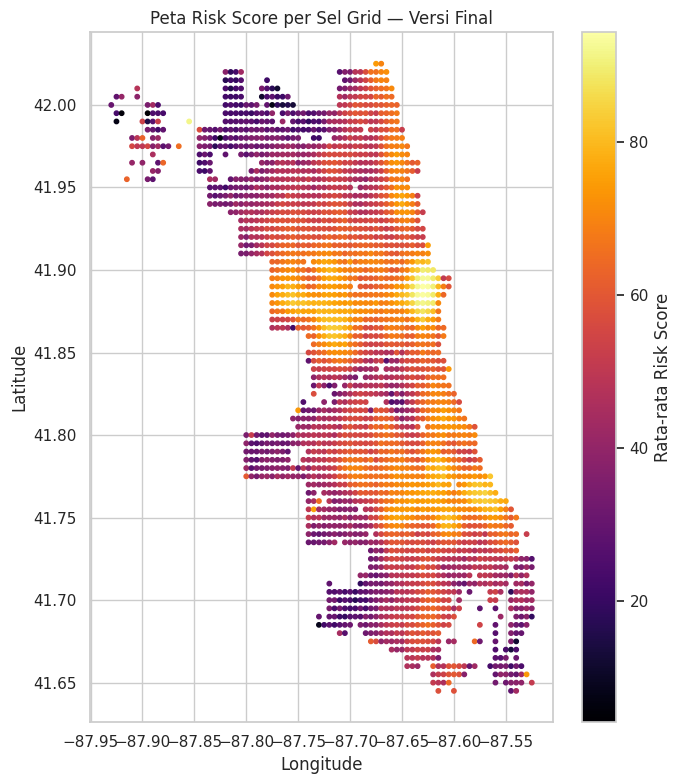

In [ ]:
cell_risk = unit.groupby(["lat_r", "lon_r"], as_index=False)["risk_score"].mean()

plt.figure(figsize=(7, 8))
sc = plt.scatter(cell_risk["lon_r"], cell_risk["lat_r"], c=cell_risk["risk_score"],
                 cmap="inferno", s=10)
plt.colorbar(sc, label="Rata-rata Risk Score")
plt.title("Peta Risk Score per Sel Grid — Versi Final")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.tight_layout(); plt.show()

**Validasi:** pola spasial rata-rata Risk Score konsisten dengan peta hotspot
hexbin di EDA (3.5) — area yang padat kejadian di EDA juga tampil dengan skor
tinggi di sini, mengonfirmasi pipeline pseudo-labeling bekerja sesuai harapan
(bukan sekadar noise acak).

# 6. Menyusun & Menyimpan Dataset Akhir

Dataset akhir berisi **fitur + label** per unit analisis (sel x hari x jam), siap
menjadi input Hands-On 2 (modeling).

In [ ]:
unit["hour_sin"], unit["hour_cos"] = cyclical_encode(unit["hour"], 24)
unit["dow_sin"], unit["dow_cos"] = cyclical_encode(unit["dow"], 7)

final = unit[[
    # identitas / lokasi
    "cell_id", "lat_r", "lon_r",
    # waktu (raw + cyclical)
    "dow", "hour", "dow_sin", "dow_cos", "hour_sin", "hour_cos",
    # fitur agregat tambahan
    "crime_count", "arrest_rate",
    # komponen label & label akhir
    "base_value", "risk_raw", "risk_score",
]].copy()

print("Shape dataset akhir:", final.shape)
print("\nMissing values:")
print(final.isna().sum().sum(), "total nilai kosong")
final.head()

Shape dataset akhir: (138663, 14)

Missing values:
0 total nilai kosong


,cell_id,lat_r,lon_r,dow,hour,dow_sin,dow_cos,hour_sin,hour_cos,crime_count,arrest_rate,base_value,risk_raw,risk_score
0,41.655_-87.535,41.655,-87.535,0,0,0.0,1.0,0.0,1.0,1,0.000000,10.966522,7.013219,56.928515
1,41.655_-87.54,41.655,-87.540,0,0,0.0,1.0,0.0,1.0,1,0.000000,11.786297,8.087732,60.557799
2,41.655_-87.55,41.655,-87.550,0,0,0.0,1.0,0.0,1.0,3,0.000000,46.822117,8.408209,61.557385
3,41.655_-87.595,41.655,-87.595,0,0,0.0,1.0,0.0,1.0,3,0.333333,56.561850,15.805209,78.288863
4,41.655_-87.6,41.655,-87.600,0,0,0.0,1.0,0.0,1.0,3,0.000000,14.616661,17.296354,80.740813


In [ ]:
final.to_csv("features_labels.csv", index=False)
print("Tersimpan: features_labels.csv")

try:
    final.to_parquet("features_labels.parquet", index=False)
    print("Tersimpan: features_labels.parquet")
except Exception as e:
    print("Parquet dilewati:", e)

Tersimpan: features_labels.csv


Tersimpan: features_labels.parquet


# 7. Ringkasan & Refleksi

**Yang dihasilkan:**
- **EDA**: pola waktu (jam/hari/interaksi keduanya, termasuk temuan artefak
  pencatatan di jam 00:00) dan lokasi (hotspot spasial jelas terkonsentrasi, tidak
  merata).
- **Fitur temporal**: cyclical encoding (`sin`/`cos`) untuk jam & hari.
- **Fitur spasial**: grid 0.005 derajat (~550 m), dipilih lewat analisis kepadatan
  data (bukan angka sembarang).
- **Risk Score (0-100)** via pseudo-labeling: severity **rule-based** (base per
  Primary Type + modifier kata kunci) x peluruhan waktu **eksponensial**
  (half-life 90 hari), dihaluskan antar-sel dengan **kernel Gaussian berbasis
  jarak haversine riil** (BallTree), lalu dinormalisasi dengan **log1p + clipping
  P99 + min-max**.
- Dataset akhir `features_labels.csv` / `.parquet` — 14 kolom, siap dimodelkan di
  Hands-On 2.

**Kendala & solusi:**
- *Long-tail kombinasi Primary Type x Description* (332 kombinasi unik) ->
  diselesaikan dengan severity **berbasis aturan**, bukan lookup manual, sehingga
  generalisasi ke kombinasi yang belum terlihat sekalipun.
- *Cakupan data hanya 1 tahun* -> fitur `month` sengaja tidak dimasukkan ke unit
  analisis akhir karena satu siklus musiman tidak cukup untuk fitur bulanan yang
  andal ini dicatat sebagai keterbatasan, bukan disembunyikan.
- *Grid lat/lon tidak isotropic* -> diatasi dengan jarak haversine riil (bukan
  jarak Euclidean sel grid) saat spatial smoothing.
- *Distribusi risk_raw sangat skewed* -> dicek langsung lewat skewness &
  histogram, lalu diatasi dengan log1p + percentile clipping sebelum min-max.


